<a href="https://colab.research.google.com/github/AnhNgoc201/Deeplearning/blob/main/Thuchanh_Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Huấn luyện model bằng mô hình CNN


## Cài đặt thư viện

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

## Đọc dữ liệu MNIST

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

## Trực quan hóa 10 ảnh đầu

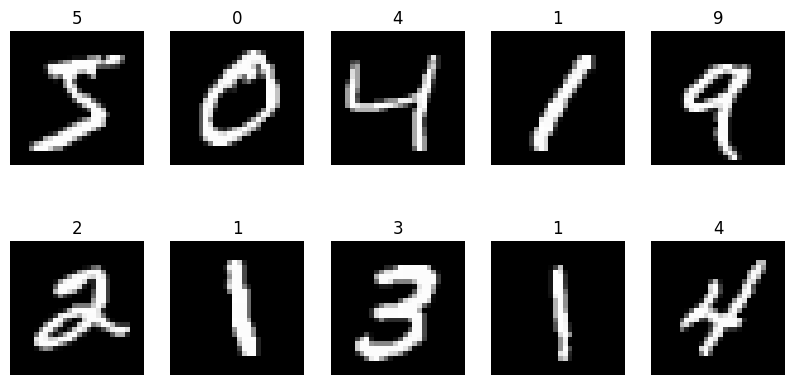

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

## Tiền xử lí dữ liệu

### Chuẩn hóa

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Reshape

In [5]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

### One-hot encoding

In [6]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## Xây dựng mô hình CNN

In [7]:
model = models.Sequential()

# Convolution + ReLU + Pooling
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten + Dense
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile model

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Huấn luyện model

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9872 - val_loss: 0.0440
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.9892 - val_loss: 0.0346
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9967 - loss: 0.0093 - val_accuracy: 0.9905 - val_loss: 0.0345
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9974 - loss: 0.0076 - val_accuracy: 0.9891 - val_loss: 0.0433
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9975 - loss: 0.0071 - val_accuracy: 0.9879 - val_loss: 0.0529
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 29ms/step - accuracy: 0.9980 - loss: 0.0065 - val_accuracy: 0.9911 - val_loss: 0.0379
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 29ms/step - accuracy: 0.9983 - loss: 0.0048 - val_accuracy: 0.9912 - val_loss: 0.0429
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 29ms/step - accuracy: 0.9980 -

## Đánh giá mô hình

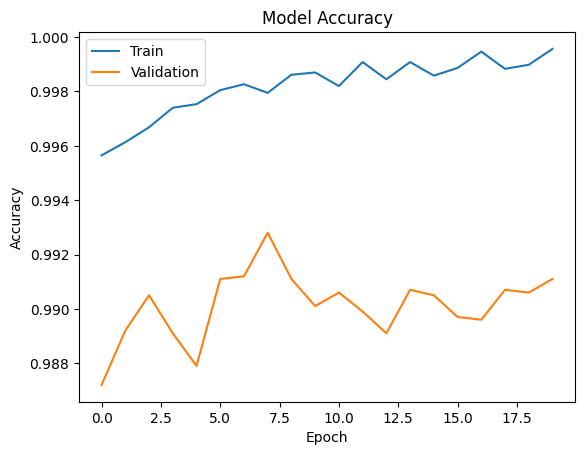

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

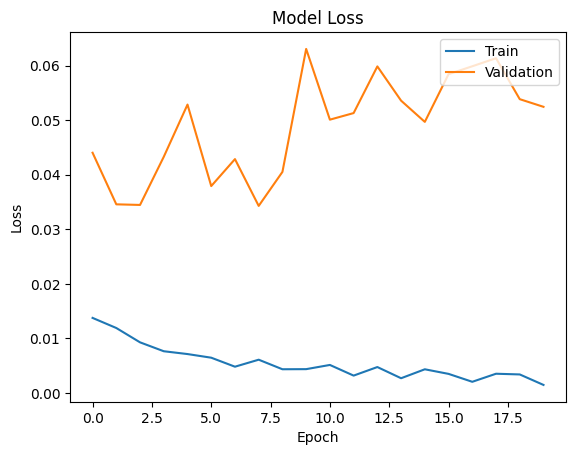

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

## Dự đoán thử

In [19]:
import numpy as np

pred = model.predict(X_test)

print("Dự đoán:", np.argmax(pred[0]))
print("Thực tế:", np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Dự đoán: 7
Thực tế: 7


## Lưu model

In [20]:
model.save("cnn_mnist.h5")

## Dự đoán ảnh thật

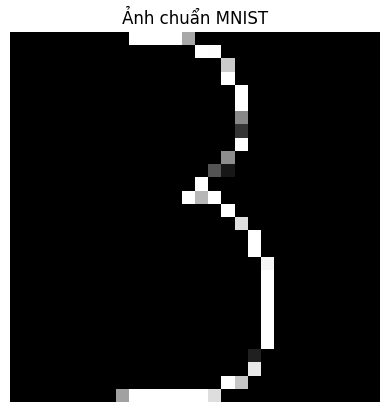

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Dự đoán: 3
Độ tin cậy: 94.72 %


In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/h10.png", 0)

img = cv2.GaussianBlur(img, (5,5), 0)

_, img = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)

coords = np.column_stack(np.where(img > 0))
y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

img = img[y_min:y_max, x_min:x_max]

h, w = img.shape
if h > w:
    new_h = 28
    new_w = int(w * 28 / h)
else:
    new_w = 28
    new_h = int(h * 28 / w)

img = cv2.resize(img, (new_w, new_h))

canvas = np.zeros((28,28))

y_offset = (28 - new_h) // 2
x_offset = (28 - new_w) // 2

canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img

img = canvas

img = img / 255.0

plt.imshow(img, cmap='gray')
plt.title("Ảnh chuẩn MNIST")
plt.axis('off')
plt.show()

img_input = img.reshape(1,28,28,1)
pred = model.predict(img_input)

print("Dự đoán:", np.argmax(pred))
print("Độ tin cậy:", round(np.max(pred)*100,2), "%")